In [2]:
# 1. 导包
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 生成模拟数据
X, y_true = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=1.0, random_state=42)

# 3. 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# 4. K-Means 聚类（k=3）
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# SSE（簇内误差平方和，即 inertia）
sse = kmeans.inertia_
# SC（轮廓系数，越接近 1 越好）
sc = silhouette_score(X_scaled, labels)

print(f"聚类数 k = {k}")
print(f"SSE（误差平方和）: {sse:.2f}")
print(f"SC（轮廓系数）: {sc:.4f}")

聚类数 k = 3
SSE（误差平方和）: 18.26
SC（轮廓系数）: 0.8482


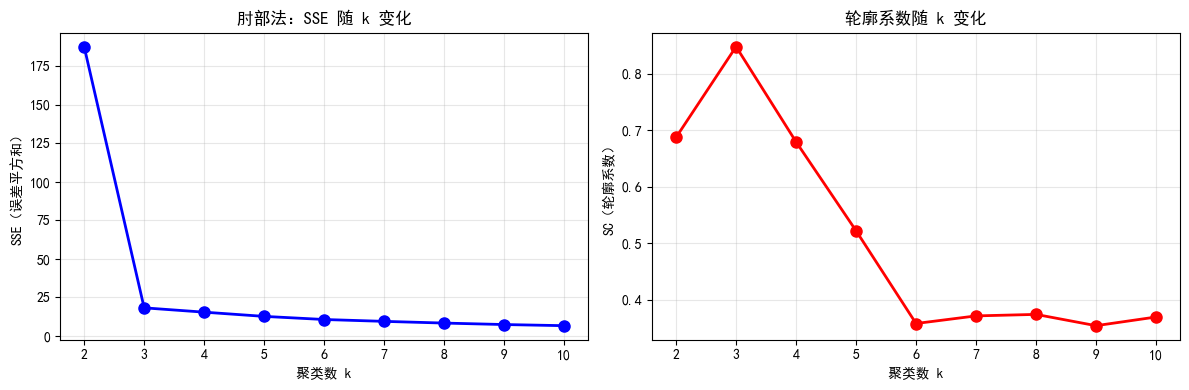

  k           SSE        SC
----------------------------
  2        187.80    0.6875
  3         18.26    0.8482
  4         15.46    0.6795
  5         12.72    0.5219
  6         10.69    0.3575
  7          9.48    0.3709
  8          8.37    0.3736
  9          7.42    0.3536
 10          6.68    0.3690


In [4]:
# 5. 肘部法：遍历不同 k，记录 SSE 与 SC
k_range = range(2, 11)
sse_list = []
sc_list = []

for n_clusters in k_range:
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    pred = km.fit_predict(X_scaled)
    sse_list.append(km.inertia_)
    sc_list.append(silhouette_score(X_scaled, pred))

# 绘制肘部法曲线（SSE）
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, sse_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('聚类数 k')
axes[0].set_ylabel('SSE（误差平方和）')
axes[0].set_title('肘部法：SSE 随 k 变化')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# 轮廓系数随 k 变化
axes[1].plot(k_range, sc_list, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('聚类数 k')
axes[1].set_ylabel('SC（轮廓系数）')
axes[1].set_title('轮廓系数随 k 变化')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印各 k 的评估指标
print(f"{'k':>3}  {'SSE':>12}  {'SC':>8}")
print("-" * 28)
for i, n in enumerate(k_range):
    print(f"{n:>3}  {sse_list[i]:>12.2f}  {sc_list[i]:>8.4f}")

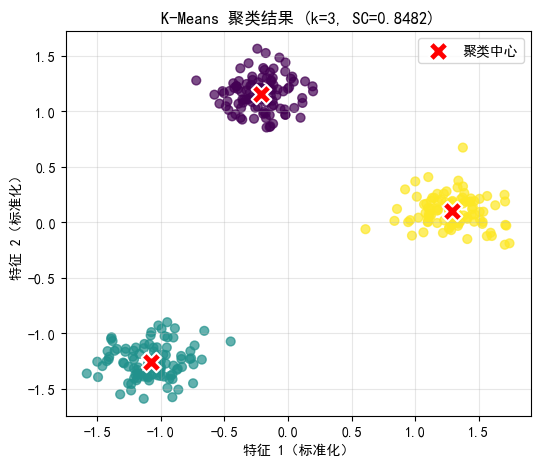

In [5]:
# 6. 可视化聚类结果（k=3）
plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=40, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, linewidths=1.5, edgecolors='white', label='聚类中心')
plt.xlabel('特征 1（标准化）')
plt.ylabel('特征 2（标准化）')
plt.title(f'K-Means 聚类结果 (k={k}, SC={sc:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()